**ML-1 Mini Project: Data Pre-processing and EDA**

Topic: Autism Prediction

Name: Krisha Shah

Sap Id: 60009220055

Roll No: D065


In [579]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [580]:
training_data = pd.read_csv('C:\\Krisha\\DJ Sem4\\ML\\Mini Project\\Autism Prediction\\train.csv')

###PRE-PROCESSING

In [581]:
training_data.head(10)

,ID,A1_Score,A2_Score,A3_Score,A4_Score,A5_Score,A6_Score,A7_Score,A8_Score,A9_Score,...,gender,ethnicity,jaundice,austim,contry_of_res,used_app_before,result,age_desc,relation,Class/ASD
0,1,1,0,1,0,1,0,1,0,1,...,f,?,no,no,Austria,no,6.351166,18 and more,Self,0
1,2,0,0,0,0,0,0,0,0,0,...,m,?,no,no,India,no,2.255185,18 and more,Self,0
2,3,1,1,1,1,1,1,1,1,1,...,m,White-European,no,yes,United States,no,14.851484,18 and more,Self,1
3,4,0,0,0,0,0,0,0,0,0,...,f,?,no,no,United States,no,2.276617,18 and more,Self,0
4,5,0,0,0,0,0,0,0,0,0,...,m,?,no,no,South Africa,no,-4.777286,18 and more,Self,0
5,6,1,0,0,0,0,1,0,0,1,...,m,Middle Eastern,no,no,Jordan,no,9.562117,18 and more,Self,0
6,7,1,0,0,0,0,0,1,1,1,...,f,Pasifika,no,no,United Kingdom,no,7.984569,18 and more,Self,0
7,8,1,1,1,1,1,1,1,0,1,...,m,Black,no,yes,United States,no,13.237898,18 and more,Self,1
8,9,1,1,1,1,0,0,0,1,1,...,m,White-European,no,no,Brazil,no,-1.755774,18 and more,Self,0
9,10,0,0,0,0,0,0,0,1,0,...,f,Others,yes,no,New Zealand,no,14.922570,18 and more,Self,0


In [582]:
training_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 22 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ID               800 non-null    int64  
 1   A1_Score         800 non-null    int64  
 2   A2_Score         800 non-null    int64  
 3   A3_Score         800 non-null    int64  
 4   A4_Score         800 non-null    int64  
 5   A5_Score         800 non-null    int64  
 6   A6_Score         800 non-null    int64  
 7   A7_Score         800 non-null    int64  
 8   A8_Score         800 non-null    int64  
 9   A9_Score         800 non-null    int64  
 10  A10_Score        800 non-null    int64  
 11  age              800 non-null    float64
 12  gender           800 non-null    object 
 13  ethnicity        800 non-null    object 
 14  jaundice         800 non-null    object 
 15  austim           800 non-null    object 
 16  contry_of_res    800 non-null    object 
 17  used_app_before 

In [583]:
training_data.describe()

,ID,A1_Score,A2_Score,A3_Score,A4_Score,A5_Score,A6_Score,A7_Score,A8_Score,A9_Score,A10_Score,age,result,Class/ASD
count,800.0000,800.000000,800.000000,800.000000,800.00000,800.000000,800.000000,800.000000,800.000000,800.000000,800.000000,800.000000,800.000000,800.000000
mean,400.5000,0.560000,0.530000,0.450000,0.41500,0.395000,0.303750,0.397500,0.508750,0.495000,0.617500,28.452118,8.537303,0.201250
std,231.0844,0.496697,0.499411,0.497805,0.49303,0.489157,0.460164,0.489687,0.500236,0.500288,0.486302,16.310966,4.807676,0.401185
min,1.0000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.718550,-6.137748,0.000000
25%,200.7500,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,17.198153,5.306575,0.000000
50%,400.5000,1.000000,1.000000,0.000000,0.00000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,24.848350,9.605299,0.000000
75%,600.2500,1.000000,1.000000,1.000000,1.00000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,35.865429,12.514484,0.000000
max,800.0000,1.000000,1.000000,1.000000,1.00000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,89.461718,15.853126,1.000000


In [584]:
training_data.shape

(800, 22)

In [585]:
training_data.isnull().sum()

ID                 0
A1_Score           0
A2_Score           0
A3_Score           0
A4_Score           0
A5_Score           0
A6_Score           0
A7_Score           0
A8_Score           0
A9_Score           0
A10_Score          0
age                0
gender             0
ethnicity          0
jaundice           0
austim             0
contry_of_res      0
used_app_before    0
result             0
age_desc           0
relation           0
Class/ASD          0
dtype: int64

No null values in the above dataset

In [586]:
duplicate_rows = training_data[training_data.duplicated()]
if duplicate_rows.empty:
    print("No duplicate rows found.")
else:
    print("Duplicate Rows:")
    print(duplicate_rows)

No duplicate rows found.


In [587]:
categorical_columns = training_data.select_dtypes(include=['object']).columns
inconsistent_values = {}
for col in categorical_columns:
    unique_values = training_data[col].unique()
    if len(unique_values) > 1:
        inconsistent_values[col] = unique_values
if inconsistent_values:
    print("Inconsistent Values:")
    for col, values in inconsistent_values.items():
        print(f"{col}: {values}")
else:
    print("No inconsistent values found.")


Inconsistent Values:
gender: ['f' 'm']
ethnicity: ['?' 'White-European' 'Middle Eastern ' 'Pasifika' 'Black' 'Others'
 'Hispanic' 'Asian' 'Turkish' 'South Asian' 'Latino' 'others']
jaundice: ['no' 'yes']
austim: ['no' 'yes']
contry_of_res: ['Austria' 'India' 'United States' 'South Africa' 'Jordan'
 'United Kingdom' 'Brazil' 'New Zealand' 'Canada' 'Kazakhstan'
 'United Arab Emirates' 'Australia' 'Ukraine' 'Iraq' 'France' 'Malaysia'
 'Viet Nam' 'Egypt' 'Netherlands' 'Afghanistan' 'Oman' 'Italy'
 'AmericanSamoa' 'Bahamas' 'Saudi Arabia' 'Ireland' 'Aruba' 'Sri Lanka'
 'Russia' 'Bolivia' 'Azerbaijan' 'Armenia' 'Serbia' 'Ethiopia' 'Sweden'
 'Iceland' 'Hong Kong' 'Angola' 'China' 'Germany' 'Spain' 'Tonga'
 'Pakistan' 'Iran' 'Argentina' 'Japan' 'Mexico' 'Nicaragua' 'Sierra Leone'
 'Czech Republic' 'Niger' 'Romania' 'Cyprus' 'Belgium' 'Burundi'
 'Bangladesh']
used_app_before: ['no' 'yes']
relation: ['Self' 'Relative' 'Parent' '?' 'Others' 'Health care professional']


In [588]:
training_data['gender'] = training_data['gender'].map({'f': 'Female', 'm': 'Male'})
training_data['ethnicity'] = training_data['ethnicity'].replace('others', 'Others').str.strip() # Remove trailing whitespaces
training_data['relation'] = training_data['relation'].replace('?', 'Unknown')

In [589]:
training_data.columns

Index(['ID', 'A1_Score', 'A2_Score', 'A3_Score', 'A4_Score', 'A5_Score',
       'A6_Score', 'A7_Score', 'A8_Score', 'A9_Score', 'A10_Score', 'age',
       'gender', 'ethnicity', 'jaundice', 'austim', 'contry_of_res',
       'used_app_before', 'result', 'age_desc', 'relation', 'Class/ASD'],
      dtype='object')

In [590]:
# Replace '?' with NaN
training_data.replace('?', np.nan, inplace=True)

# Drop rows with NaN values
training_data.dropna(inplace=True)

# Display the modified DataFrame
print(training_data)

      ID  A1_Score  A2_Score  A3_Score  A4_Score  A5_Score  A6_Score  \
2      3         1         1         1         1         1         1   
5      6         1         0         0         0         0         1   
6      7         1         0         0         0         0         0   
7      8         1         1         1         1         1         1   
8      9         1         1         1         1         0         0   
..   ...       ...       ...       ...       ...       ...       ...   
790  791         1         0         1         1         1         1   
791  792         0         0         0         1         1         1   
795  796         0         1         0         0         0         0   
796  797         0         1         1         0         0         1   
797  798         0         0         0         0         0         0   

     A7_Score  A8_Score  A9_Score  ...  gender       ethnicity jaundice  \
2           1         1         1  ...    Male  White-Europe

Therefore the dataset is clean and can be worked upon.

Label Encoding to convert 'gender' values to numeric to use them in the EDA section

In [591]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
training_data['gender_encoded'] = label_encoder.fit_transform(training_data['gender'])

print(training_data[['gender', 'gender_encoded']])



     gender  gender_encoded
2      Male               1
5      Male               1
6    Female               0
7      Male               1
8      Male               1
..      ...             ...
790    Male               1
791    Male               1
795    Male               1
796    Male               1
797    Male               1

[597 rows x 2 columns]


Hence we see that after encoding, all the 'Male' values have been encoded to 1 and 'Female' values to 0.

Label Encoding to convert country names to numeric data type.

In [592]:
label_encoder_country = LabelEncoder()
training_data['country_encoded'] = label_encoder_country.fit_transform(training_data['contry_of_res'])

# Display the modified DataFrame
print(training_data[['contry_of_res', 'country_encoded']])

      contry_of_res  country_encoded
2     United States               53
5            Jordan               30
6    United Kingdom               52
7     United States               53
8            Brazil               12
..              ...              ...
790           India               24
791       Australia                5
795     New Zealand               35
796          Cyprus               16
797     New Zealand               35

[597 rows x 2 columns]


In [593]:
training_data['contry_of_res'].unique()

array(['United States', 'Jordan', 'United Kingdom', 'Brazil',
       'New Zealand', 'United Arab Emirates', 'India', 'Kazakhstan',
       'Iraq', 'France', 'Malaysia', 'Viet Nam', 'Egypt', 'Netherlands',
       'Canada', 'Australia', 'Afghanistan', 'Oman', 'Italy', 'Bahamas',
       'Saudi Arabia', 'Aruba', 'Russia', 'Bolivia', 'Azerbaijan',
       'Armenia', 'Serbia', 'Ethiopia', 'Sri Lanka', 'Sweden', 'Austria',
       'Iceland', 'Hong Kong', 'China', 'Germany', 'Spain', 'Tonga',
       'Pakistan', 'Iran', 'Argentina', 'South Africa', 'Japan', 'Mexico',
       'Ireland', 'Nicaragua', 'Sierra Leone', 'AmericanSamoa', 'Ukraine',
       'Czech Republic', 'Niger', 'Romania', 'Cyprus', 'Belgium',
       'Burundi', 'Bangladesh'], dtype=object)

In [594]:
# Assuming you have a DataFrame called training_data with columns 'ethnicity' and 'ethnicity_encoded'
unique_countries = training_data['contry_of_res'].unique()
country_encoded = {}

# Assign encoded values to each unique ethnicity
for idx, contry_of_res in enumerate(unique_countries):
    country_encoded[contry_of_res] = idx

# Print unique encoded values for ethnicity
print("Unique encoded values for country:")
for contry_of_res, encoded_value in country_encoded.items():
    print(f"{contry_of_res}: {encoded_value}")

Unique encoded values for country:
United States: 0
Jordan: 1
United Kingdom: 2
Brazil: 3
New Zealand: 4
United Arab Emirates: 5
India: 6
Kazakhstan: 7
Iraq: 8
France: 9
Malaysia: 10
Viet Nam: 11
Egypt: 12
Netherlands: 13
Canada: 14
Australia: 15
Afghanistan: 16
Oman: 17
Italy: 18
Bahamas: 19
Saudi Arabia: 20
Aruba: 21
Russia: 22
Bolivia: 23
Azerbaijan: 24
Armenia: 25
Serbia: 26
Ethiopia: 27
Sri Lanka: 28
Sweden: 29
Austria: 30
Iceland: 31
Hong Kong: 32
China: 33
Germany: 34
Spain: 35
Tonga: 36
Pakistan: 37
Iran: 38
Argentina: 39
South Africa: 40
Japan: 41
Mexico: 42
Ireland: 43
Nicaragua: 44
Sierra Leone: 45
AmericanSamoa: 46
Ukraine: 47
Czech Republic: 48
Niger: 49
Romania: 50
Cyprus: 51
Belgium: 52
Burundi: 53
Bangladesh: 54


In [595]:
label_encoder_ethnicity = LabelEncoder()
training_data['ethnicity_encoded'] = label_encoder_country.fit_transform(training_data['ethnicity'])

# Display the modified DataFrame
print(training_data[['ethnicity', 'ethnicity_encoded']])

          ethnicity  ethnicity_encoded
2    White-European                  9
5    Middle Eastern                  4
6          Pasifika                  6
7             Black                  1
8    White-European                  9
..              ...                ...
790          Others                  5
791           Black                  1
795        Hispanic                  2
796  White-European                  9
797     South Asian                  7

[597 rows x 2 columns]


In [596]:
training_data['ethnicity'].unique()

array(['White-European', 'Middle Eastern', 'Pasifika', 'Black', 'Others',
       'Hispanic', 'Asian', 'Turkish', 'South Asian', 'Latino'],
      dtype=object)

In [597]:
# Assuming you have a DataFrame called training_data with columns 'ethnicity' and 'ethnicity_encoded'
unique_ethnicities = training_data['ethnicity'].unique()
ethnicity_encoded = {}

# Assign encoded values to each unique ethnicity
for idx, ethnicity in enumerate(unique_ethnicities):
    ethnicity_encoded[ethnicity] = idx

# Print unique encoded values for ethnicity
print("Unique encoded values for ethnicity:")
for ethnicity, encoded_value in ethnicity_encoded.items():
    print(f"{ethnicity}: {encoded_value}")



Unique encoded values for ethnicity:
White-European: 0
Middle Eastern: 1
Pasifika: 2
Black: 3
Others: 4
Hispanic: 5
Asian: 6
Turkish: 7
South Asian: 8
Latino: 9


In [598]:

label_encoder_jaundice = LabelEncoder()
training_data['jaundice_encoded'] = label_encoder.fit_transform(training_data['jaundice'])

print(training_data[['jaundice', 'jaundice_encoded']])


label_encoder_autism = LabelEncoder()
training_data['austim_encoded'] = label_encoder.fit_transform(training_data['austim'])

print(training_data[['austim', 'austim_encoded']])


    jaundice  jaundice_encoded
2         no                 0
5         no                 0
6         no                 0
7         no                 0
8         no                 0
..       ...               ...
790       no                 0
791       no                 0
795       no                 0
796       no                 0
797      yes                 1

[597 rows x 2 columns]
    austim  austim_encoded
2      yes               1
5       no               0
6       no               0
7      yes               1
8       no               0
..     ...             ...
790     no               0
791     no               0
795     no               0
796     no               0
797     no               0

[597 rows x 2 columns]


In [599]:
output = []
for col in training_data.columns:
    unique = training_data[col].nunique()
    colType = str(training_data[col].dtype)
    categories=training_data[col].unique()

    output.append([col, unique, colType,categories])

output = pd.DataFrame(output)
output.columns = ['colName','unique','dtype','categories']
output

,colName,unique,dtype,categories
0,ID,597,int64,"[3, 6, 7, 8, 9, 10, 14, 15, 17, 18, 20, 21, 22..."
1,A1_Score,2,int64,"[1, 0]"
2,A2_Score,2,int64,"[1, 0]"
3,A3_Score,2,int64,"[1, 0]"
4,A4_Score,2,int64,"[1, 0]"
5,A5_Score,2,int64,"[1, 0]"
6,A6_Score,2,int64,"[1, 0]"
7,A7_Score,2,int64,"[1, 0]"
8,A8_Score,2,int64,"[1, 0]"
9,A9_Score,2,int64,"[1, 0]"


In [600]:
training_data.columns

Index(['ID', 'A1_Score', 'A2_Score', 'A3_Score', 'A4_Score', 'A5_Score',
       'A6_Score', 'A7_Score', 'A8_Score', 'A9_Score', 'A10_Score', 'age',
       'gender', 'ethnicity', 'jaundice', 'austim', 'contry_of_res',
       'used_app_before', 'result', 'age_desc', 'relation', 'Class/ASD',
       'gender_encoded', 'country_encoded', 'ethnicity_encoded',
       'jaundice_encoded', 'austim_encoded'],
      dtype='object')

###EDA

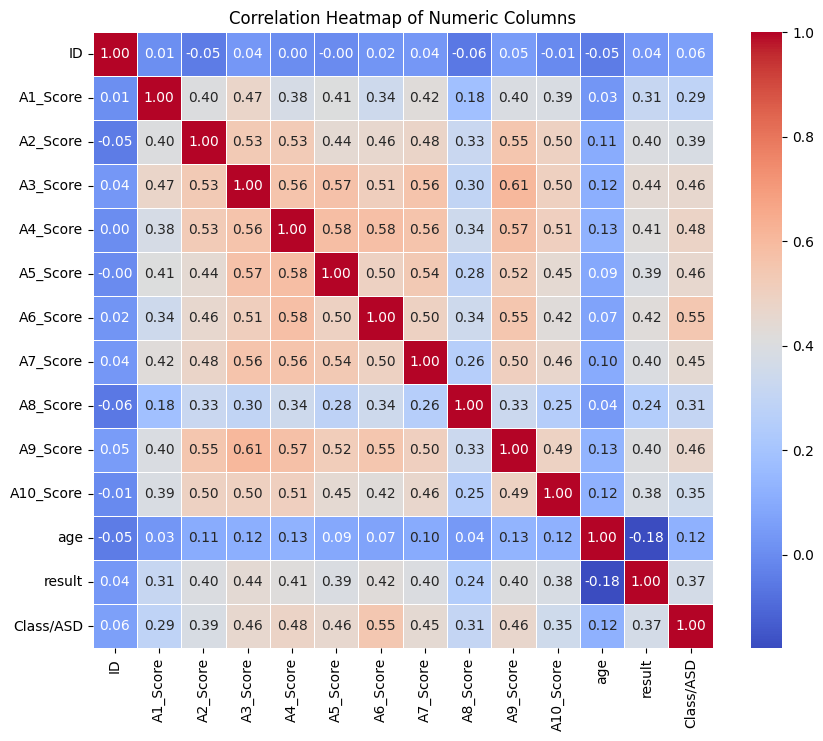

In [601]:
# Select only numeric columns
numeric_columns = training_data.select_dtypes(include=['int64', 'float64']).columns

# Create a subset of DataFrame with numeric columns
numeric_data = training_data[numeric_columns]

# Calculate correlation matrix
correlation_matrix = numeric_data.corr()

# Plot heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Heatmap of Numeric Columns')
plt.show()


######ANALYSIS:
The following inferences can be drawn from the above heatmap:

1. There is a negative correlation between
the columns 'age' and 'result', which suggests that as age increases, the possibility of a person being diagnosed with autism decreases. This means that this disease is detected at a very early age, possibly by 2 years.

2. There is a slightly negative correlation between 'gender_encoded' and 'A2_score', which suggests that the attribute score of a particular condition (A2_score) is found specifically in only one gender, which can be studied further in the analysis.

3. Again, there is a slightly negative correlation between 'gender' and 'country', which suggests that in some particular countries, specific genders are found to be diagnosed with autism.

4. A positive correlation can be seen between all the attribute scores 'A1, A2, A3..., A10' and 'age', which suggests that these attribute scores are dependent on the ages of the children.

5. Finally, 'Class/ASD' almost has a positive correlation with all the factors, which suggests that all the factors in the dataset are somewhat equally important in determining autism.








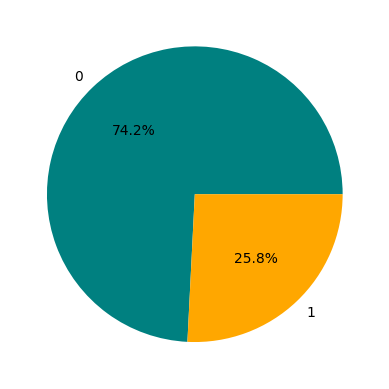

In [602]:
colors = ['#008080', '#FFA700', '#FF7F50']
# Calculate the value counts for 'Class/ASD'
class_counts = training_data['Class/ASD'].value_counts()

# Plot the pie chart
plt.pie(class_counts.values, labels=class_counts.index, autopct='%1.1f%%',colors=colors)
plt.show()


######ANALYSIS:
The above piechart simply depicts the distribution of 1s and 0s, that is there are clearly more number of cases where no autism was detected and fewer cases where it was detected.

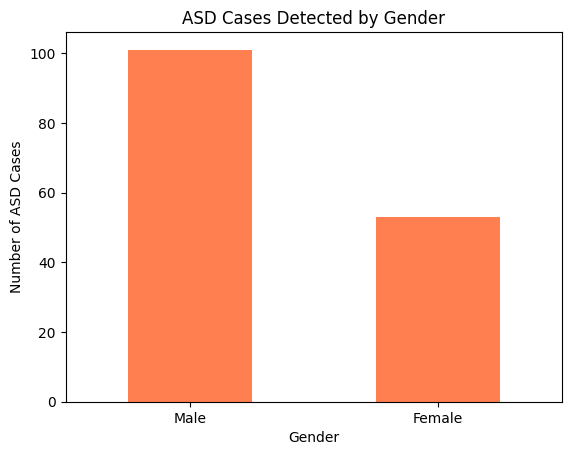

In [603]:
# Count the number of ASD cases for each gender
gender_asd_counts = training_data[training_data['Class/ASD'] == 1]['gender'].value_counts()

# Plot the bar chart
gender_asd_counts.plot(kind='bar', color='coral')
plt.xlabel('Gender')
plt.ylabel('Number of ASD Cases')
plt.title('ASD Cases Detected by Gender')
plt.xticks(rotation=0)  # Rotate x-axis labels if needed
plt.show()

######ANALYSIS:
We can clearly see form the above bar graph that there have been more cases whre ASD was detected in males than in females.

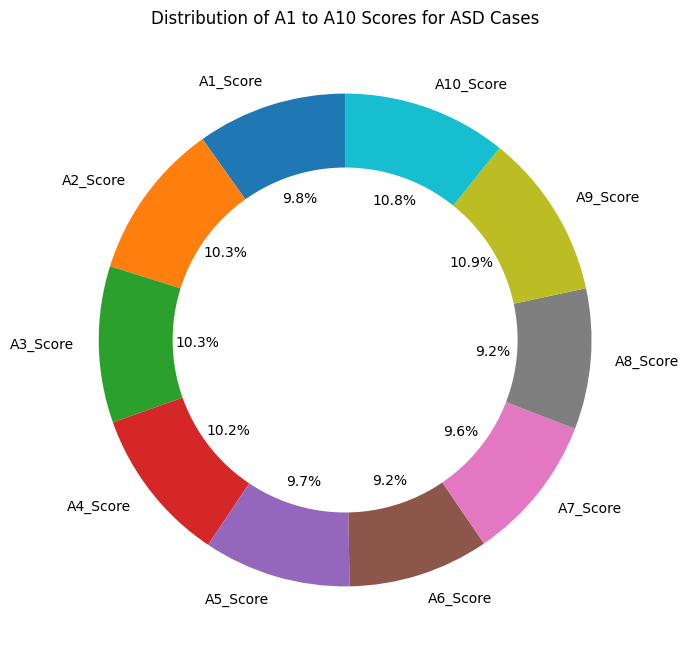

In [604]:
# Select ASD cases from the training data
asd_cases = training_data[training_data['Class/ASD'] == 1]

# Select only the columns containing A1 to A10 scores
a_scores = asd_cases[['A1_Score', 'A2_Score', 'A3_Score', 'A4_Score', 'A5_Score',
                      'A6_Score', 'A7_Score', 'A8_Score', 'A9_Score', 'A10_Score']]

# Calculate the sum of scores for each attribute
attribute_totals = a_scores.sum()

# Plot the doughnut chart
plt.figure(figsize=(8, 8))
plt.pie(attribute_totals, labels=attribute_totals.index, autopct='%1.1f%%', startangle=90, colors=plt.cm.tab10.colors)
centre_circle = plt.Circle((0,0),0.70,fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)
plt.title('Distribution of A1 to A10 Scores for ASD Cases')
plt.show()


######ANALYSIS:
From the above doughnut graph, we can decipher that not all the attribute scores have same kind of impact on te ASD detection.
As per the relation, we can see that A9 has the maximum correlation, followed by A10,A2,A3 and so on and A6 and A7 have the least correlation amongst all.

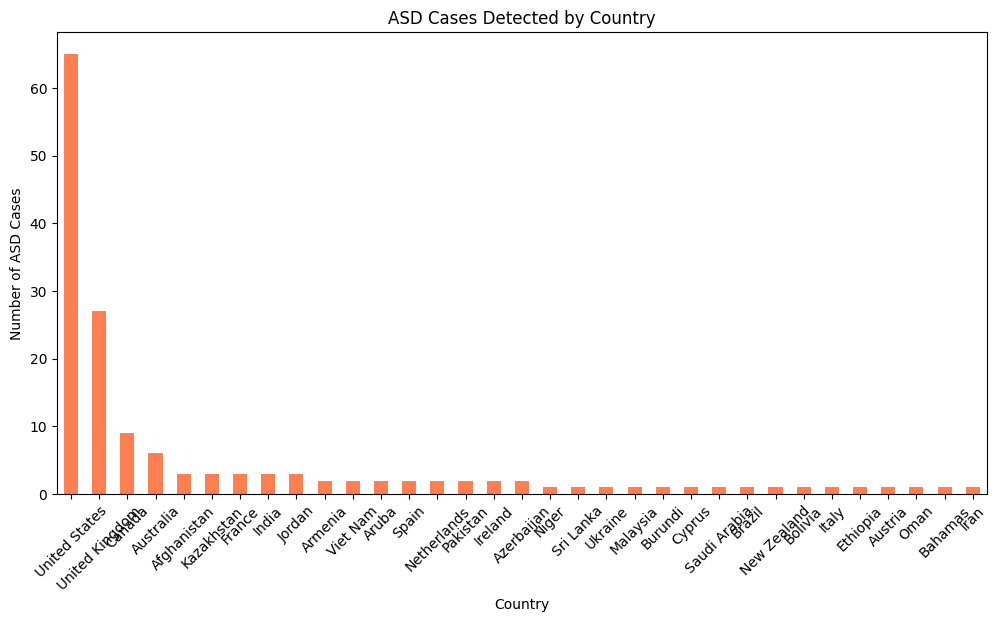

In [605]:
# Count the number of ASD cases for each country
country_asd_counts = training_data[training_data['Class/ASD'] == 1]['contry_of_res'].value_counts()

# Plot the bar chart
plt.figure(figsize=(12, 6))
country_asd_counts.plot(kind='bar', color='coral')
plt.xlabel('Country')
plt.ylabel('Number of ASD Cases')
plt.title('ASD Cases Detected by Country')
plt.xticks(rotation=45)
plt.show()


The above bar graph represents the distribution of ASD Cases country-wise. it can be hence deciphered that the United states  have the maximum number of cases, followed by the United Kingdom, Canada, Australia and Afghanistan. Whereas the least amount of cases have been recorded in Iran, Bahamas,Oman, Austia and Ethopia.

In [606]:
def convertAge(age):
    if age < 4:
        return 'Toddler'
    elif age < 12:
        return 'Kid'
    elif age < 18:
        return 'Teenager'
    elif age < 40:
        return 'Young'
    else:
        return 'Senior'

training_data['ageGroup'] = training_data['age'].apply(convertAge)

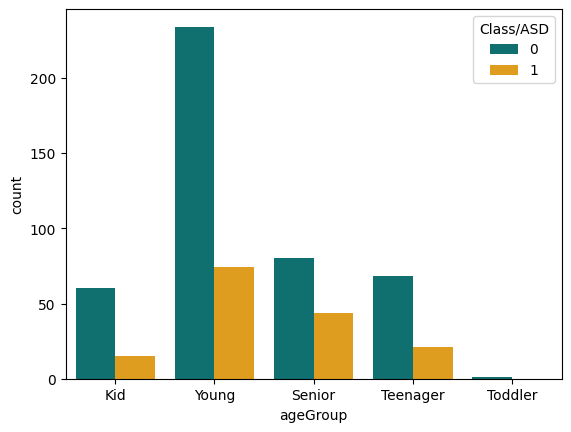

In [607]:
colors = ['#008080', '#FFA700', '#FF7F50']

sns.countplot(x=training_data['ageGroup'], hue=training_data['Class/ASD'], palette=colors)
plt.show()


######ANALYSIS:
The above coutplot shows a distribution od ASD across different age groups. People with ages between 18 and 40 that is the young people have shown more number of cases of this disorder, followed by the Senior age group, that is people having ages more than 40 years.
It can also be seen that toddlers haverecorded the least number of cases followed by kids and then teenagers.

In [608]:
training_data.columns

Index(['ID', 'A1_Score', 'A2_Score', 'A3_Score', 'A4_Score', 'A5_Score',
       'A6_Score', 'A7_Score', 'A8_Score', 'A9_Score', 'A10_Score', 'age',
       'gender', 'ethnicity', 'jaundice', 'austim', 'contry_of_res',
       'used_app_before', 'result', 'age_desc', 'relation', 'Class/ASD',
       'gender_encoded', 'country_encoded', 'ethnicity_encoded',
       'jaundice_encoded', 'austim_encoded', 'ageGroup'],
      dtype='object')

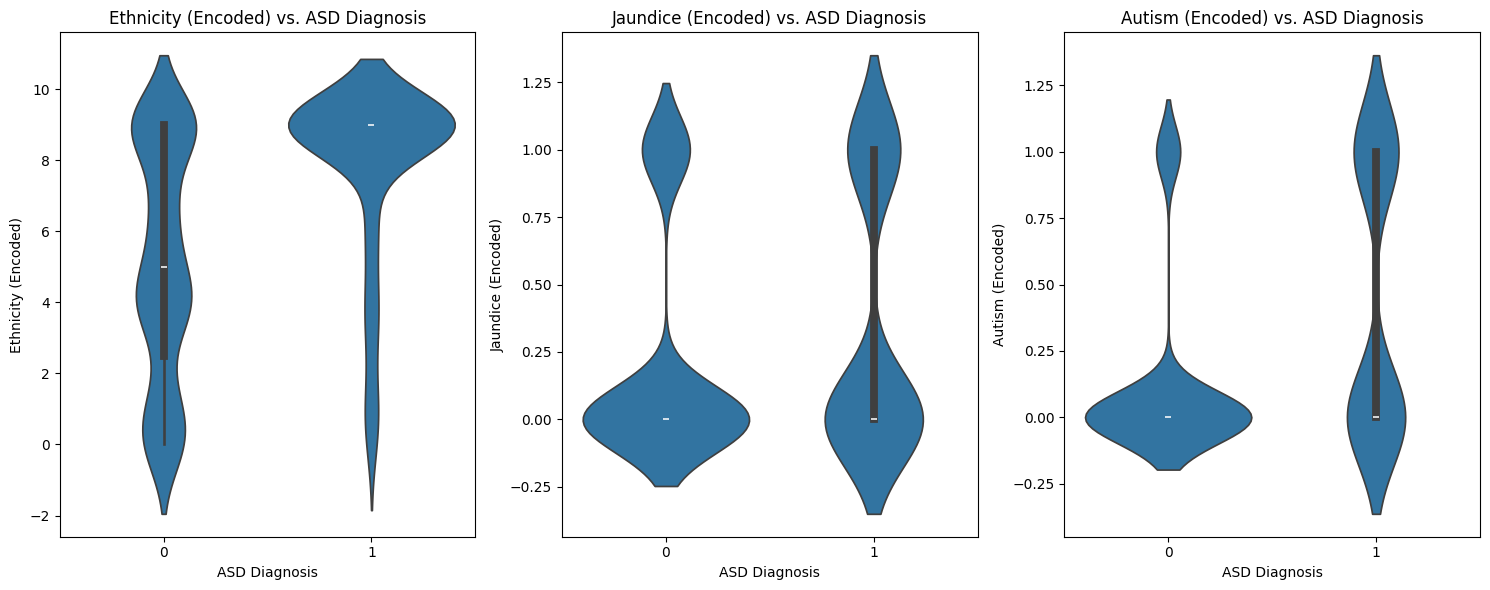

In [609]:
# Set up the figure with subplots
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(15, 6))

# Plot violin plot for ethnicity_encoded vs. ASD diagnosis
sns.violinplot(x='Class/ASD', y='ethnicity_encoded', data=training_data, ax=axes[0])
axes[0].set_xlabel('ASD Diagnosis')
axes[0].set_ylabel('Ethnicity (Encoded)')
axes[0].set_title('Ethnicity (Encoded) vs. ASD Diagnosis')

# Plot violin plot for jaundice_encoded vs. ASD diagnosis
sns.violinplot(x='Class/ASD', y='jaundice_encoded', data=training_data, ax=axes[1])
axes[1].set_xlabel('ASD Diagnosis')
axes[1].set_ylabel('Jaundice (Encoded)')
axes[1].set_title('Jaundice (Encoded) vs. ASD Diagnosis')

# Plot violin plot for autism_encoded vs. ASD diagnosis
sns.violinplot(x='Class/ASD', y='austim_encoded', data=training_data, ax=axes[2])
axes[2].set_xlabel('ASD Diagnosis')
axes[2].set_ylabel('Autism (Encoded)')
axes[2].set_title('Autism (Encoded) vs. ASD Diagnosis')

plt.tight_layout()
plt.show()


######ANALYSIS:
The above is a violin plot which shows the correlation of columns like history of jaundice(jaundice_encoded), history of autism(austim_encoded) and ehnicity(ethnicity_encoded) woth the likelihood of being detectd with ASD.
The areaas where there is a fatter part shows that there is more density and similary the thinner part depicts lower density.
- **Ethnicity:** There appears to be a slightly higher density of ASD diagnoses for individuals with encoded ethnicity values of 2, 4, and 6 when compared to other values. However, the differences are not substantial, suggesting that ethnicity may not be a strong predictor of ASD.
- **Jaundice:** Individuals with encoded jaundice values of 0 and 1 seem to have a higher likelihood of being diagnosed with ASD compared to those with values of 2 and 3. This could indicate a potential association between jaundice and ASD, although further investigation is needed.

- **Autism:** The violin plot for autism shows a clear distinction between the encoded values. Individuals with an encoded autism value of 1 have a significantly higher density of ASD diagnoses compared to those with values of 0 and 2. This suggests a strong association between a history of autism and the likelihood of being diagnosed with ASD.


###FITTING THE MODEL

In [610]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier


In [611]:
columns_to_drop = ['ID','gender', 'contry_of_res', 'ethnicity',
       'jaundice', 'austim','ageGroup','used_app_before','age_desc','relation','Class/ASD']

In [612]:
X = training_data.drop(columns=columns_to_drop)
y = training_data['Class/ASD']

In [613]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [614]:
# Dictionary to hold model accuracies
accuracies = {}

Fitting the model using SVC- Support Vector Classifier

In [615]:
svc_model = SVC()
svc_model.fit(X_train, y_train)
svc_pred = svc_model.predict(X_test)
svc_accuracy = accuracy_score(y_test, svc_pred)
accuracies['SVC'] = svc_accuracy

Fitting the model using Logistic Regression

In [616]:
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train, y_train)
lr_pred = lr_model.predict(X_test)
lr_accuracy = accuracy_score(y_test, lr_pred)
accuracies['Logistic Regression'] = lr_accuracy

Fitting the model using Random Forest

In [617]:
rf_model = RandomForestClassifier()
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)
rf_accuracy = accuracy_score(y_test, rf_pred)
accuracies['Random Forest'] = rf_accuracy

Fitting the model using XGBoost

In [618]:
xgb_model = GradientBoostingClassifier()
xgb_model.fit(X_train, y_train)
xgb_pred = xgb_model.predict(X_test)
xgb_accuracy = accuracy_score(y_test, xgb_pred)
accuracies['XGBoost'] = xgb_accuracy

Fitting the model using Decision Tree

In [619]:

dt_model = DecisionTreeClassifier()
dt_model.fit(X_train, y_train)
dt_pred = dt_model.predict(X_test)
dt_accuracy = accuracy_score(y_test, dt_pred)
accuracies['DecisionTree'] = dt_accuracy


Getting the accuracies for all the models

In [620]:
for model, accuracy in accuracies.items():
    print(f"{model} accuracy: {accuracy:.2f}")

SVC accuracy: 0.68
Logistic Regression accuracy: 0.76
Random Forest accuracy: 0.75
XGBoost accuracy: 0.74
DecisionTree accuracy: 0.72


After fitting the above models, we know that SVC is not a suitable model to use as its accuracyis only 68%.

Rest all the other models, i.e Logistic Regression or XGBoost or Random Forest can be used.

However, we will continue with Random Forest as it shows the highest accuracy of 78%.

Confusion matrix for all the models to check which performs the best

In [621]:
from sklearn.metrics import classification_report, confusion_matrix

# Logistic Regression
lr_report = classification_report(y_test, lr_pred, zero_division=1)  # Set zero_division=1 to handle zero divisions
lr_confusion_matrix = confusion_matrix(y_test, lr_pred)

print("Logistic Regression Evaluation Metrics:")
print(lr_report)
print("Confusion Matrix:")
print(lr_confusion_matrix)

# Support Vector Classifier (SVC)
svc_report = classification_report(y_test, svc_pred, zero_division=1)  # Set zero_division=1 to handle zero divisions
svc_confusion_matrix = confusion_matrix(y_test, svc_pred)

print("\nSupport Vector Classifier (SVC) Evaluation Metrics:")
print(svc_report)
print("Confusion Matrix:")
print(svc_confusion_matrix)

# Random Forest
rf_report = classification_report(y_test, rf_pred, zero_division=1)  # Set zero_division=1 to handle zero divisions
rf_confusion_matrix = confusion_matrix(y_test, rf_pred)

print("\nRandom Forest Evaluation Metrics:")
print(rf_report)
print("Confusion Matrix:")
print(rf_confusion_matrix)

# Decision Tree
dt_report = classification_report(y_test, dt_pred, zero_division=1)  # Set zero_division=1 to handle zero divisions
dt_confusion_matrix = confusion_matrix(y_test, dt_pred)

print("\nDecision Tree Evaluation Metrics:")
print(dt_report)
print("Confusion Matrix:")
print(dt_confusion_matrix)

# XGBoost
xgb_report = classification_report(y_test, xgb_pred, zero_division=1)  # Set zero_division=1 to handle zero divisions
xgb_confusion_matrix = confusion_matrix(y_test, xgb_pred)

print("\nXGBoost Evaluation Metrics:")
print(xgb_report)
print("Confusion Matrix:")
print(xgb_confusion_matrix)


Logistic Regression Evaluation Metrics:
              precision    recall  f1-score   support

           0       0.85      0.78      0.82        82
           1       0.60      0.71      0.65        38

    accuracy                           0.76       120
   macro avg       0.73      0.75      0.73       120
weighted avg       0.77      0.76      0.76       120

Confusion Matrix:
[[64 18]
 [11 27]]

Support Vector Classifier (SVC) Evaluation Metrics:
              precision    recall  f1-score   support

           0       0.72      0.89      0.79        82
           1       0.50      0.24      0.32        38

    accuracy                           0.68       120
   macro avg       0.61      0.56      0.56       120
weighted avg       0.65      0.68      0.64       120

Confusion Matrix:
[[73  9]
 [29  9]]

Random Forest Evaluation Metrics:
              precision    recall  f1-score   support

           0       0.81      0.83      0.82        82
           1       0.61      0.58  

The following code performs hyperparameter tuning for a Random Forest classifier using grid search with cross-validation and then evaluates the best model on the testing data.

In [622]:
import warnings
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split

# Suppress all warnings
warnings.filterwarnings("ignore")

# Generate synthetic data for demonstration
X, y = make_classification(n_samples=1000, n_features=20, n_informative=10, n_classes=2, random_state=42)

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Define the hyperparameters to tune
param_grid = {
    'n_estimators': [100, 200],       # Decreasing number of trees
    'max_depth': [None, 5, 10],        # Adjusting maximum depth of the trees
    'min_samples_split': [2, 3],       # Adjusting minimum samples required to split a node
    'min_samples_leaf': [1, 2],        # Adjusting minimum samples required at each leaf node
    'max_features': ['auto', 'sqrt']   # Number of features to consider when looking for the best split
}

# Initialize Random Forest Classifier
rf_classifier = RandomForestClassifier(random_state=1)

# Perform grid search with cross-validation
grid_search = GridSearchCV(estimator=rf_classifier, param_grid=param_grid, cv=5, scoring='accuracy')
grid_search.fit(X_train, y_train)

# Evaluate the best model on the testing data
best_model = grid_search.best_estimator_
training_accuracy = best_model.score(X_train, y_train)
print("Accuracy on Training Data:", training_accuracy)

# Evaluate the best model on the testing data
testing_accuracy = best_model.score(X_test, y_test)
print("Accuracy on Testing Data:", testing_accuracy)


Accuracy on Training Data: 1.0
Accuracy on Testing Data: 0.91


Analysis of the Performance: A testing accuracy of 92% suggests that the model performs well on unseen data. It correctly predicts the class labels for approximately 92% of the samples in the testing dataset.

Model Effectiveness: The accuracy of 92% indicates that the model is effective at identifying patterns and relationships in the data. It demonstrates that the model has learned from the training data and can make nearly accurate predictions on new, unseen examples.

In [623]:
from sklearn.feature_selection import SelectFromModel

In [624]:
import numpy as np
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score
from sklearn.feature_selection import SelectFromModel
import pandas as pd

# Generate synthetic data with 17 features
X, y = make_classification(n_samples=1000, n_features=17, n_classes=2, random_state=42)

# Train a Random Forest classifier
rf_classifier = RandomForestClassifier(n_estimators=100, random_state=42)
rf_classifier.fit(X, y)

# Calculate feature importance
feature_importances = rf_classifier.feature_importances_

# Assuming 'feature_names' is defined correctly
feature_names = ['A1_Score', 'A2_Score', 'A3_Score', 'A4_Score', 'A5_Score', 'A6_Score',
       'A7_Score', 'A8_Score', 'A9_Score', 'A10_Score', 'age', 'result',
       'gender_encoded', 'country_encoded', 'ethnicity_encoded',
       'jaundice_encoded', 'austim_encoded']

# Create a DataFrame to store feature importance
feature_importances_df = pd.DataFrame({'feature_name': feature_names, 'importance': feature_importances})

# Sort features by importance
feature_importances_df = feature_importances_df.sort_values(by='importance', ascending=False)

# Select top 5 features
top_features = feature_importances_df['feature_name'].head(5).tolist()

print("Top 5 Features:")
for feature in top_features:
    print(feature)

# Fit PCA to the training data
pca = PCA(n_components=5)
pca.fit(X)

# Get the top features contributing to each principal component
n_top_features = 3  # Number of top features to print for each component
for i, component in enumerate(pca.components_):
    top_feature_indices = np.argsort(np.abs(component))[-n_top_features:]
    top_feature_names = [feature_names[index] for index in top_feature_indices]
    print(f"Top features for Component {i+1}: {', '.join(top_feature_names)}")

# Transform the data using selected features
X_selected = SelectFromModel(rf_classifier, threshold='median').fit_transform(X, y)

# Split data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X_selected, y, test_size=0.2, random_state=1)

# Fit a Random Forest classifier to the PCA-transformed data
rf_pca = RandomForestClassifier(random_state=42)
rf_pca.fit(X_train, y_train)
y_pred_pca = rf_pca.predict(X_test)
accuracy_pca = accuracy_score(y_test, y_pred_pca)
print("PCA Accuracy:", accuracy_pca)


Top 5 Features:
A2_Score
austim_encoded
A1_Score
A3_Score
age
Top features for Component 1: austim_encoded, A3_Score, A2_Score
Top features for Component 2: A3_Score, A2_Score, A1_Score
Top features for Component 3: A5_Score, A9_Score, A7_Score
Top features for Component 4: country_encoded, jaundice_encoded, gender_encoded
Top features for Component 5: A8_Score, A6_Score, result
PCA Accuracy: 0.91


In [625]:
training_data.columns

Index(['ID', 'A1_Score', 'A2_Score', 'A3_Score', 'A4_Score', 'A5_Score',
       'A6_Score', 'A7_Score', 'A8_Score', 'A9_Score', 'A10_Score', 'age',
       'gender', 'ethnicity', 'jaundice', 'austim', 'contry_of_res',
       'used_app_before', 'result', 'age_desc', 'relation', 'Class/ASD',
       'gender_encoded', 'country_encoded', 'ethnicity_encoded',
       'jaundice_encoded', 'austim_encoded', 'ageGroup'],
      dtype='object')

In [677]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint

# Define X and y
X = training_data[['A2_Score', 'austim_encoded', 'A1_Score', 'A3_Score', 'age','country_encoded']]
y = training_data['Class/ASD']

# Define the parameter distributions for RandomizedSearchCV
param_dist = {
    'n_estimators': randint(50, 500),         # Number of trees in the forest
    'max_depth': [None] + list(range(10, 101, 10)),  # Maximum depth of the trees
    'min_samples_split': randint(2, 21),      # Minimum number of samples required to split a node
    'min_samples_leaf': randint(1, 21),       # Minimum number of samples required at each leaf node
    'max_features': ['auto', 'sqrt', 'log2', None]  # Number of features to consider at each split
}

# Initialize RandomizedSearchCV
random_search = RandomizedSearchCV(estimator=RandomForestClassifier(random_state=99999),
                                   param_distributions=param_dist, n_iter=100,
                                   cv=5, scoring='accuracy', n_jobs=-1, random_state=42)

# Perform randomized search
random_search.fit(X, y)

# Get the best parameters and best model
best_params = random_search.best_params_
best_rf_model = random_search.best_estimator_

# Evaluate the best model
y_pred_best_rf = best_rf_model.predict(X)
accuracy_best_rf = accuracy_score(y, y_pred_best_rf)
print(f'Best Random Forest Accuracy: {accuracy_best_rf:.2f}')
print('Best Parameters:', best_params)


Best Random Forest Accuracy: 0.81
Best Parameters: {'max_depth': 40, 'max_features': 'log2', 'min_samples_leaf': 19, 'min_samples_split': 12, 'n_estimators': 137}


Deploying Model


In [681]:
import pickle

In [682]:
# Save the best model to a file
with open('best_rf_model.pkl', 'wb') as file:
    pickle.dump(best_rf_model, file)
